<a href="https://colab.research.google.com/github/feridehmedovv200/OIBSIP/blob/main/DataAnalytics-Task2-CustomerSegmentation/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
df = pd.read_csv('/content/E-Commerce.csv', encoding='ISO-8859-1')

In [ ]:
print("--- Initial Inspection ---")
print(df.info())
print(df.isnull().sum())

--- Initial Inspection ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3599 entries, 0 to 3598
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       3599 non-null   int64  
 1   Gender           3599 non-null   object 
 2   InvoiceDate      3599 non-null   object 
 3   InvoiceNumber    3599 non-null   int64  
 4   ProductID        3599 non-null   int64  
 5   Quantity         3599 non-null   int64  
 6   Price            3599 non-null   float64
 7   Total            3599 non-null   float64
 8   OrderStatus      3599 non-null   object 
 9   Country          3599 non-null   object 
 10  TrafficSource    3599 non-null   object 
 11  SessionDuration  3599 non-null   float64
 12  DeviceCategory   3599 non-null   object 
 13  Device           3599 non-null   object 
 14  OS               3599 non-null   object 
 15  DeliveryRating   3599 non-null   int64  
 16  ProductRating    3599 non-null   

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df_clean = df[df['OrderStatus'] == 'Completed'].copy()

print("\nCleaned Data Shape:", df_clean.shape)


Cleaned Data Shape: (2245, 18)


In [ ]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

In [ ]:
rfm_df = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNumber': 'nunique',                               # Frequency
    'Total': 'sum'                                            # Monetary
}).reset_index()

In [ ]:
rfm_df.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

In [ ]:
print("--- Descriptive Statistics for RFM ---")
rfm_desc = rfm_df.describe().T
rfm_desc['median'] = rfm_df[['Recency', 'Frequency', 'Monetary']].median()
rfm_desc = rfm_desc[['count', 'mean', 'median', 'std', 'min', 'max']]
print(rfm_desc)

--- Descriptive Statistics for RFM ---
             count         mean  median          std      min     max
CustomerID  1968.0  5523.605691     NaN  2589.614132  1111.00  9998.0
Recency     1968.0   865.637195  834.50   530.116648     1.00  1826.0
Frequency   1968.0     1.140752    1.00     0.375949     1.00     3.0
Monetary    1968.0   111.893211   91.28    90.247335     1.22   597.9


In [ ]:
rfm_log = rfm_df[['Recency', 'Frequency', 'Monetary']].apply(np.log1p)

In [ ]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

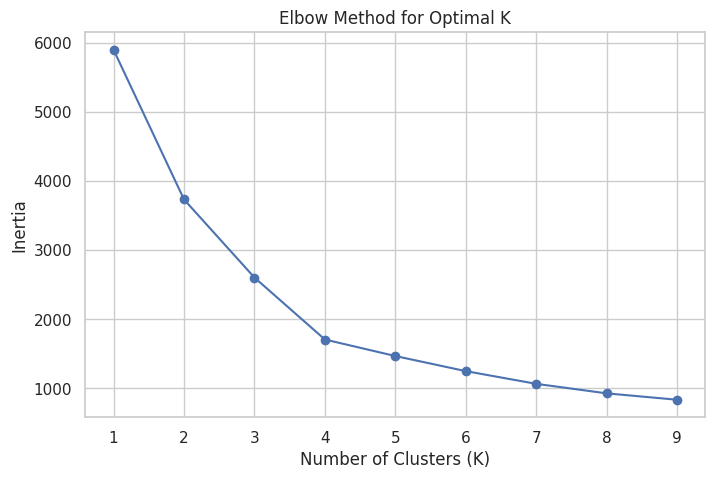

In [ ]:
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.show()

In [ ]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm_df['Cluster'] = kmeans.fit_predict(rfm_scaled)

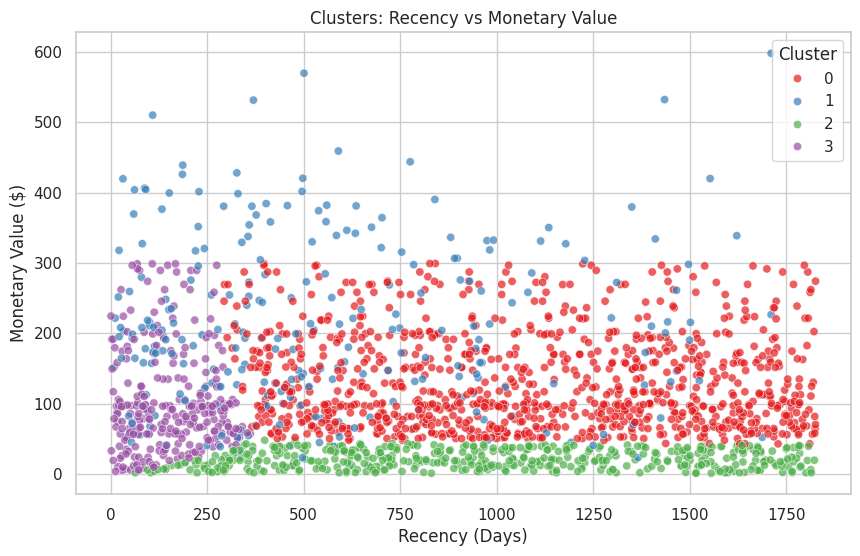

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm_df, x='Recency', y='Monetary', hue='Cluster', palette='Set1', alpha=0.7)
plt.title('Clusters: Recency vs Monetary Value')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value ($)')
plt.show()

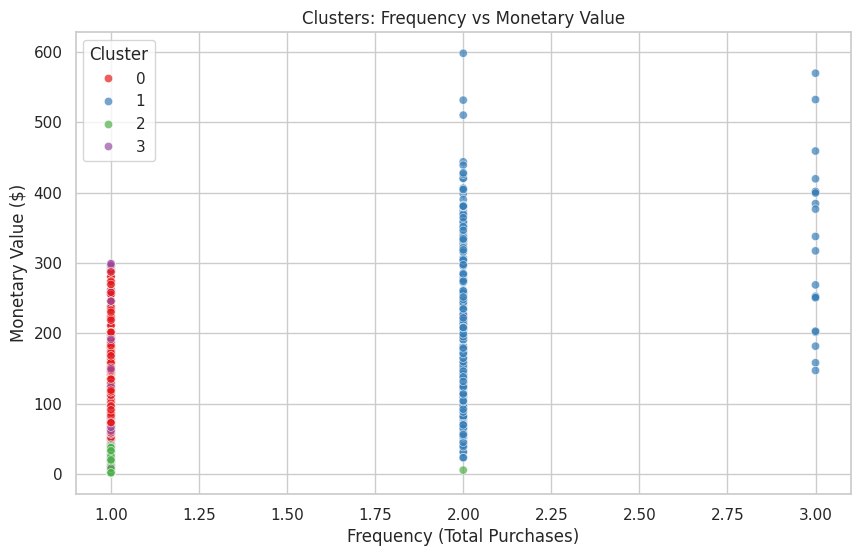

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm_df, x='Frequency', y='Monetary', hue='Cluster', palette='Set1', alpha=0.7)
plt.title('Clusters: Frequency vs Monetary Value')
plt.xlabel('Frequency (Total Purchases)')
plt.ylabel('Monetary Value ($)')
plt.show()

   Cluster  Mean_Recency  Mean_Frequency  Mean_Monetary  Customer_Count
0        0   1093.072016        1.000000     131.560329             972
1        1    566.839216        2.078431     212.275961             255
2        2    970.072650        1.002137      21.600256             468
3        3    155.934066        1.003663     102.893443             273


/tmp/ipykernel_1873/2112380667.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_profile, x='Cluster', y='Customer_Count', palette='viridis')


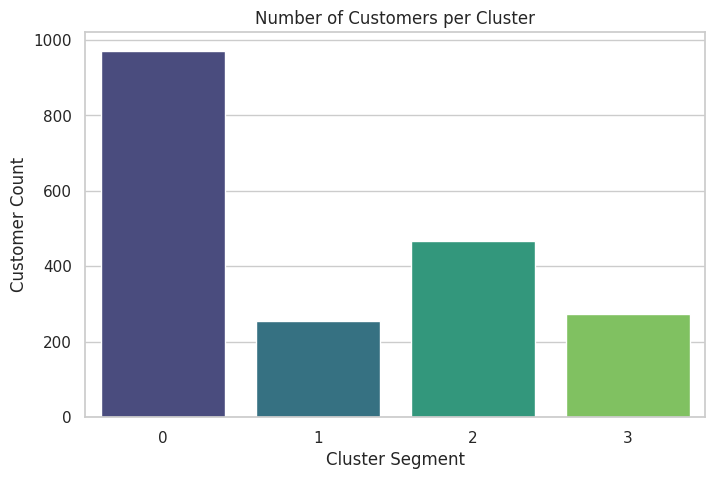

In [ ]:
cluster_profile = rfm_df.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).reset_index()

cluster_profile.columns = ['Cluster', 'Mean_Recency', 'Mean_Frequency', 'Mean_Monetary', 'Customer_Count']
print(cluster_profile)

# Bar chart: Number of customers per cluster
plt.figure(figsize=(8, 5))
sns.barplot(data=cluster_profile, x='Cluster', y='Customer_Count', palette='viridis')
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster Segment')
plt.ylabel('Customer Count')
plt.show()